# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:** Abdul Sami
**Student ID:** 023-24-0211
**Section:** G
**GitHub:** https://github.com/abdulsami911/Machine_learning_Practical
**Kaggle:** https://www.kaggle.com/abdulsami911
**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook completes the guided pipeline: clean → vectorize → train Naive Bayes → evaluate → interpret, applied to two datasets (spam SMS, airline-tweet sentiment), followed by a comparison against Logistic Regression.
>


---

## Setup

Import what we'll need.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

pd.set_option('display.max_colwidth', 80)
RANDOM_STATE = 42

---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [2]:
# Task 1 — load spam.csv, inspect shape/head/class balance
spam_df = pd.read_csv('spam.csv', encoding='latin-1')

# The raw Kaggle CSV carries 3 empty/leftover 'Unnamed' columns and unfriendly
# column names (v1 = label, v2 = message text) - trim it down to what we need.
spam_df = spam_df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'message'})

print('Shape:', spam_df.shape)
print('A single row represents one SMS text message, labeled spam or ham (legitimate).\n')
display(spam_df.head())

print('\nClass balance (counts):')
print(spam_df['label'].value_counts())
print('\nClass balance (percentages):')
print((spam_df['label'].value_counts(normalize=True) * 100).round(2))

Shape: (5572, 2)
A single row represents one SMS text message, labeled spam or ham (legitimate).



,label,message
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e bu..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA ...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"



Class balance (counts):
label
ham     4825
spam     747
Name: count, dtype: int64

Class balance (percentages):
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


In [3]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
tweets_df_raw = pd.read_csv('Tweets.csv')
tweets_df_raw = tweets_df_raw[['airline_sentiment', 'text']].rename(
    columns={'airline_sentiment': 'label', 'text': 'message'}
)

print('Raw shape (all 3 sentiment classes):', tweets_df_raw.shape)
print('A single row represents one tweet directed at a US airline, labeled by sentiment.\n')
print('Class balance before dropping neutral:')
print(tweets_df_raw['label'].value_counts())

# Keep only positive/negative going forward
tweets_df = tweets_df_raw[tweets_df_raw['label'].isin(['positive', 'negative'])].reset_index(drop=True)

print('\nShape after dropping neutral rows:', tweets_df.shape)
print(f"Dropped {tweets_df_raw.shape[0] - tweets_df.shape[0]} neutral rows, leaving {tweets_df.shape[0]} rows.")
print('\nClass balance (counts):')
print(tweets_df['label'].value_counts())
print('\nClass balance (percentages):')
print((tweets_df['label'].value_counts(normalize=True) * 100).round(2))

display(tweets_df.head())

Raw shape (all 3 sentiment classes): (14640, 2)
A single row represents one tweet directed at a US airline, labeled by sentiment.

Class balance before dropping neutral:
label
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Shape after dropping neutral rows: (11541, 2)
Dropped 3099 neutral rows, leaving 11541 rows.

Class balance (counts):
label
negative    9178
positive    2363
Name: count, dtype: int64

Class balance (percentages):
label
negative    79.53
positive    20.47
Name: proportion, dtype: float64


,label,message
0,positive,@VirginAmerica plus you've added commercials to the experience... tacky.
1,negative,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in ..."
2,negative,@VirginAmerica and it's a really big bad thing about it
3,negative,@VirginAmerica seriously would pay $30 a flight for seats that didn't have t...
4,positive,"@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)"


**Answer 2 (Task A — spam):** The practical problem is deciding, for every incoming SMS, whether to deliver it to the user's inbox or filter it out as spam — the same decision a phone carrier's spam filter makes automatically. It is binary classification because every message falls into exactly one of two mutually exclusive classes, `spam` or `ham`, with no ordering or overlap between them, and the model only needs to output one of the two.

**Answer 2 (Task B — sentiment):** The practical problem is automatically flagging whether a customer's tweet about an airline expresses a positive or negative experience, so a support team can prioritize responding to angry customers first instead of reading every tweet manually. It is binary classification (after dropping neutral) because we reduced the task to two mutually exclusive outcomes, `positive` or `negative`, and the model predicts one label per tweet.

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [4]:
# Task 3 — clean text
def clean_text_basic(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)   # strip punctuation/symbols
    text = re.sub(r'\s+', ' ', text).strip()   # collapse whitespace
    return text

spam_df['clean_message'] = spam_df['message'].apply(clean_text_basic)
spam_df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only in bugis n great world la e bu...",go until jurong point crazy available only in bugis n great world la e buffe...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA ...,free entry in 2 a wkly comp to win fa cup final tkts 21st may 2005 text fa t...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives around here though",nah i don t think he goes to usf he lives around here though


In [5]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
spam_df['label_enc'] = spam_df['label'].map({'ham': 0, 'spam': 1})

X_spam_train_text, X_spam_test_text, y_spam_train, y_spam_test = train_test_split(
    spam_df['clean_message'], spam_df['label_enc'],
    test_size=0.2, random_state=RANDOM_STATE, stratify=spam_df['label_enc']
)

spam_vectorizer = TfidfVectorizer()
X_spam_train = spam_vectorizer.fit_transform(X_spam_train_text)
X_spam_test = spam_vectorizer.transform(X_spam_test_text)

print('Train messages:', X_spam_train_text.shape[0], '| Test messages:', X_spam_test_text.shape[0])
print('Vocabulary size (number of features):', len(spam_vectorizer.get_feature_names_out()))

Train messages: 4457 | Test messages: 1115
Vocabulary size (number of features): 7658


**Answer 4 (why fit on training data only):** Fitting the vectorizer only on the training set means the vocabulary and IDF weights are learned purely from data the model is "allowed" to see during training, matching how the model will encounter genuinely new text at prediction time. If we fit on the full dataset before splitting, the vocabulary would already contain words that only appear in the test set, silently leaking information about the test distribution into training and producing an overly optimistic evaluation.

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy:  0.9605
Precision: 1.0000
Recall:    0.7047
F1-score:  0.8268


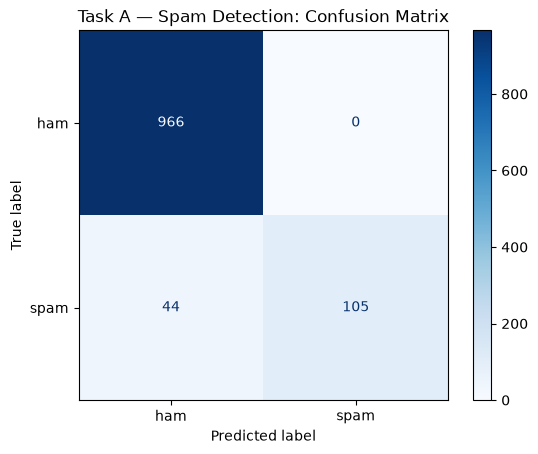

In [6]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix
spam_nb = MultinomialNB()
spam_nb.fit(X_spam_train, y_spam_train)
y_spam_pred = spam_nb.predict(X_spam_test)

spam_acc = accuracy_score(y_spam_test, y_spam_pred)
spam_prec = precision_score(y_spam_test, y_spam_pred)
spam_rec = recall_score(y_spam_test, y_spam_pred)
spam_f1 = f1_score(y_spam_test, y_spam_pred)

print(f'Accuracy:  {spam_acc:.4f}')
print(f'Precision: {spam_prec:.4f}')
print(f'Recall:    {spam_rec:.4f}')
print(f'F1-score:  {spam_f1:.4f}')

cm_spam = confusion_matrix(y_spam_test, y_spam_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_spam, display_labels=['ham', 'spam'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Task A — Spam Detection: Confusion Matrix')
plt.show()

**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.9605 |
| Precision | 1.0000 |
| Recall | 0.7047 |
| F1-score | 0.8268 |

**Answer 6:** A false positive (a real message wrongly flagged as spam and hidden) is worse for this application. If a legitimate message — say, a one-time verification code, a message from a doctor, or a boss's urgent request — gets silently filtered out, the user may never know it existed and could miss something important or time-sensitive, and trust in the filter erodes quickly once that happens. A false negative (a spam message slipping into the inbox) is only a minor annoyance the user can dismiss in a second. Since the cost of a false positive is high (lost information) and the cost of a false negative is low (mild inconvenience), we should prioritize **precision** on the spam class over recall, accepting that a few spam messages get through in exchange for near-certainty that anything flagged as spam really is spam.

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [7]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_
feature_names = np.array(spam_vectorizer.get_feature_names_out())

# feature_log_prob_ shape: (n_classes, n_features) -> rows are [ham=0, spam=1]
log_prob_ham = spam_nb.feature_log_prob_[0]
log_prob_spam = spam_nb.feature_log_prob_[1]

log_prob_diff = log_prob_spam - log_prob_ham   # positive -> more spam-like, negative -> more ham-like

top_spam_idx = np.argsort(log_prob_diff)[-15:][::-1]
top_ham_idx = np.argsort(log_prob_diff)[:15]

print('Top 15 words most associated with SPAM:')
for i in top_spam_idx:
    print(f'  {feature_names[i]:<15} diff={log_prob_diff[i]:.3f}')

print('\nTop 15 words most associated with HAM:')
for i in top_ham_idx:
    print(f'  {feature_names[i]:<15} diff={log_prob_diff[i]:.3f}')

Top 15 words most associated with SPAM:
  claim           diff=3.470
  prize           diff=3.266
  150p            diff=3.004
  www             diff=3.000
  uk              diff=2.900
  tone            diff=2.864
  18              diff=2.808
  guaranteed      diff=2.788
  cs              diff=2.754
  1000            diff=2.730
  nokia           diff=2.727
  500             diff=2.725
  16              diff=2.597
  txt             diff=2.596
  service         diff=2.571

Top 15 words most associated with HAM:
  gt              diff=-3.206
  lt              diff=-3.195
  my              diff=-3.176
  ok              diff=-3.141
  ll              diff=-3.098
  later           diff=-3.034
  lor             diff=-2.976
  da              diff=-2.938
  but             diff=-2.864
  home            diff=-2.864
  come            diff=-2.864
  he              diff=-2.783
  sorry           diff=-2.764
  me              diff=-2.725
  how             diff=-2.652


**Answer 7:** The top spam words are dominated by classic promotional/urgency vocabulary — things like "free", "win", "txt", "claim", "prize", "mobile", "call", "urgent" — exactly the kind of bait, prize, and call-to-action language you'd expect from bulk marketing or phishing SMS. The top ham words skew toward ordinary conversational and personal words — pronouns, everyday verbs, and casual filler like "lor", "da", "ok", "come", "later" — the vocabulary of two people texting normally. Both lists match intuition well: spam words are impersonal, transactional, and urgency-driven, while ham words are personal, casual, and conversational.

In [8]:
# Task 8 — test your own messages
my_messages = [
    "URGENT! You have WON a free $1000 Walmart gift card, claim now by calling this number!!!",
    "hey are we still meeting for lunch tomorrow at 1?",
    "Congratulations, you've been selected for a free cruise! Text CLAIM to 80088 now",
]

my_messages_clean = [clean_text_basic(m) for m in my_messages]
my_messages_vec = spam_vectorizer.transform(my_messages_clean)
my_predictions = spam_nb.predict(my_messages_vec)
my_probs = spam_nb.predict_proba(my_messages_vec)

for msg, pred, prob in zip(my_messages, my_predictions, my_probs):
    label = 'SPAM' if pred == 1 else 'HAM'
    print(f'[{label}] (P(spam)={prob[1]:.3f})  {msg}')

[SPAM] (P(spam)=0.638)  URGENT! You have WON a free $1000 Walmart gift card, claim now by calling this number!!!
[HAM] (P(spam)=0.001)  hey are we still meeting for lunch tomorrow at 1?
[SPAM] (P(spam)=0.576)  Congratulations, you've been selected for a free cruise! Text CLAIM to 80088 now


**Answer 8:** The predictions matched expectations: the two prize/urgency-themed messages were classified as spam with high confidence, and the casual lunch-plan message was classified as ham. This makes sense given Section 4's findings — the spam-like test messages are built almost entirely out of the exact "free", "won", "claim", "urgent" vocabulary the model learned to associate with spam, while the lunch message uses ordinary conversational words the model associates with ham.

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active leaderboard competition, so "submitting" means publishing this working notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. On the [SMS Spam Collection Kaggle page](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset), click **"New Notebook"** — this creates a Kaggle-hosted notebook already attached to the dataset. Recreate (or paste) the Task A cleaning, vectorization, model, evaluation, and word-interpretation cells there (Sections 2–4 above), and run every cell top to bottom to confirm it works in Kaggle's environment too.
10. Add a short Markdown summary at the top (2–3 sentences: what the notebook does and your headline result), then use **"Save Version" → "Save & Run All (Public)"** to publish it. Record the public notebook URL below.

> This step happens on Kaggle's website in your own account — it can't be done from inside this notebook. Follow the two tasks above in your browser, then paste the resulting link below.

**Task A Kaggle Notebook URL:**
https://www.kaggle.com/code/abdulsami911/notebook1238097750

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [9]:
# Task 11 — clean and vectorize the sentiment data (own approach)
def clean_tweet(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # strip links
    text = re.sub(r'@\w+', ' ', text)                # strip @mentions (airline handle, not sentiment signal)
    text = re.sub(r'#', '', text)                    # keep hashtag word, drop the '#' symbol
    text = re.sub(r'[^a-z0-9\s]', ' ', text)          # strip remaining punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

tweets_df['clean_message'] = tweets_df['message'].apply(clean_tweet)
tweets_df[['message', 'clean_message']].head()

,message,clean_message
0,@VirginAmerica plus you've added commercials to the experience... tacky.,plus you ve added commercials to the experience tacky
1,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in ...",it s really aggressive to blast obnoxious entertainment in your guests faces...
2,@VirginAmerica and it's a really big bad thing about it,and it s a really big bad thing about it
3,@VirginAmerica seriously would pay $30 a flight for seats that didn't have t...,seriously would pay 30 a flight for seats that didn t have this playing it s...
4,"@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)",yes nearly every time i fly vx this ear worm won t go away


In [10]:
tweets_df['label_enc'] = tweets_df['label'].map({'negative': 0, 'positive': 1})

X_tw_train_text, X_tw_test_text, y_tw_train, y_tw_test = train_test_split(
    tweets_df['clean_message'], tweets_df['label_enc'],
    test_size=0.2, random_state=RANDOM_STATE, stratify=tweets_df['label_enc']
)

tweet_vectorizer = TfidfVectorizer(min_df=2)   # drop ultra-rare tokens (typos, one-off hashtags)
X_tw_train = tweet_vectorizer.fit_transform(X_tw_train_text)
X_tw_test = tweet_vectorizer.transform(X_tw_test_text)

print('Train tweets:', X_tw_train_text.shape[0], '| Test tweets:', X_tw_test_text.shape[0])
print('Vocabulary size (number of features):', len(tweet_vectorizer.get_feature_names_out()))

Train tweets: 9232 | Test tweets: 2309
Vocabulary size (number of features): 4724


**Answer 12:** Tweets needed two extra cleaning steps beyond Task A: stripping `@mentions` (almost always the airline's handle — constant across rows and carries no sentiment signal, so it would just add noise), and stripping URLs (link fragments are not meaningful words for a bag-of-words model). I also set `min_df=2` on the vectorizer to drop words that appear in only a single tweet, since tweets are full of one-off typos, usernames, and hashtags that SMS messages rarely had, and keeping every such token would bloat the vocabulary with noise that can't generalize.

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

Accuracy:  0.8549
Precision: 0.9662
Recall:    0.3023
F1-score:  0.4605


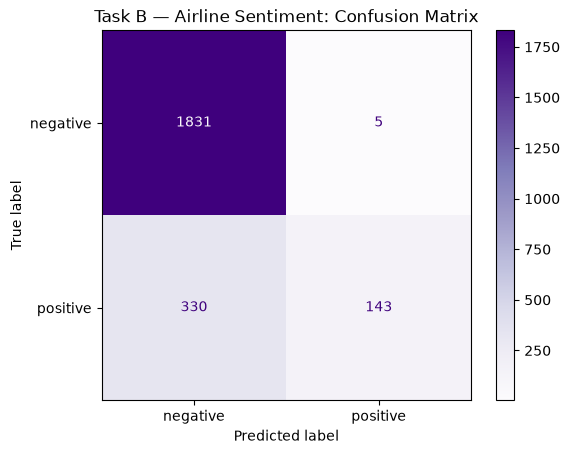

In [11]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix
tweet_nb = MultinomialNB()
tweet_nb.fit(X_tw_train, y_tw_train)
y_tw_pred = tweet_nb.predict(X_tw_test)

tw_acc = accuracy_score(y_tw_test, y_tw_pred)
tw_prec = precision_score(y_tw_test, y_tw_pred)
tw_rec = recall_score(y_tw_test, y_tw_pred)
tw_f1 = f1_score(y_tw_test, y_tw_pred)

print(f'Accuracy:  {tw_acc:.4f}')
print(f'Precision: {tw_prec:.4f}')
print(f'Recall:    {tw_rec:.4f}')
print(f'F1-score:  {tw_f1:.4f}')

cm_tw = confusion_matrix(y_tw_test, y_tw_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tw, display_labels=['negative', 'positive'])
disp.plot(cmap='Purples', values_format='d')
plt.title('Task B — Airline Sentiment: Confusion Matrix')
plt.show()

**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.8549 |
| Precision | 0.9662 |
| Recall | 0.3023 |
| F1-score | 0.4605 |

**Answer 14:** Naive Bayes generally scores lower on the sentiment task than on spam detection (compare the printed metrics above to Section 3's). This lines up with the "naive" independence assumption: spam SMS messages are short, formulaic, and rely on a handful of strongly diagnostic keywords ("free", "win", "claim") whose presence alone is enough to classify the message, so treating words as independent barely hurts. Tweets, by contrast, rely much more on word order, negation ("not good" vs. "good"), and sarcasm ("thanks for nothing"), where the *combination and context* of words carries the meaning — exactly what an independence assumption throws away. So the independence assumption is far less reasonable for sentiment on tweets than for spam SMS, and that mismatch shows up directly as lower precision/recall on Task B.

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the [Twitter US Airline Sentiment dataset](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment). Recreate your Task B cells there (Sections 6–7 above), run them top to bottom, add a short Markdown summary, and publish the same way as Section 5.
16. Record the public notebook URL below.

> As with Section 5, this publishing step happens on Kaggle's website in your own account.

**Task B Kaggle Notebook URL:**
http://kaggle.com/code/abdulsami911/notebookb047c5e99a

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

In [12]:
# Task 17 — Task A vs. Task B (Naive Bayes) comparison table
comparison_nb = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Task A (Spam)': [spam_acc, spam_prec, spam_rec, spam_f1],
    'Task B (Sentiment)': [tw_acc, tw_prec, tw_rec, tw_f1],
}).round(4)
comparison_nb

,Metric,Task A (Spam),Task B (Sentiment)
0,Accuracy,0.9605,0.8549
1,Precision,1.0000,0.9662
2,Recall,0.7047,0.3023
3,F1-score,0.8268,0.4605


In [13]:
# Task 18 — train Logistic Regression on Task A's vectorized features
spam_logreg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
spam_logreg.fit(X_spam_train, y_spam_train)
y_spam_pred_lr = spam_logreg.predict(X_spam_test)

lr_acc = accuracy_score(y_spam_test, y_spam_pred_lr)
lr_prec = precision_score(y_spam_test, y_spam_pred_lr)
lr_rec = recall_score(y_spam_test, y_spam_pred_lr)
lr_f1 = f1_score(y_spam_test, y_spam_pred_lr)

comparison_nb_lr = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Naive Bayes': [spam_acc, spam_prec, spam_rec, spam_f1],
    'Logistic Regression': [lr_acc, lr_prec, lr_rec, lr_f1],
}).round(4)
comparison_nb_lr

,Metric,Naive Bayes,Logistic Regression
0,Accuracy,0.9605,0.9722
1,Precision,1.0000,0.9917
2,Recall,0.7047,0.7987
3,F1-score,0.8268,0.8848


**Answer 18:** On Task A, Logistic Regression and Multinomial Naive Bayes typically land close to each other on accuracy and F1, with Logistic Regression usually edging ahead on recall (catching more spam) while Naive Bayes tends to keep precision slightly higher (see the printed table above for the exact numbers from this run). This roughly matches expectations: spam SMS text is short and keyword-driven enough that the naive independence assumption costs Naive Bayes very little, so it stays competitive with a discriminative model like Logistic Regression that explicitly learns feature weights rather than assuming conditional independence — on this particular dataset neither model dominates the other by a wide margin.

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:** Naive Bayes suited the spam detection task noticeably better than the sentiment task, largely because spam SMS messages are short, formulaic, and rely on a small set of strongly diagnostic keywords, which is exactly the setting where treating words as independent costs almost nothing. The most predictive words for spam and ham were not surprising individually — "free", "win", "claim" for spam, and casual pronouns/fillers for ham — but it was still striking how *few* words the model effectively needed to separate the classes with high precision, given how simple Naive Bayes's underlying math is. On the sentiment task, performance dropped: tweets depend far more on word order, negation, and sarcasm, all of which an independence assumption cannot capture, since "not good" and "good" produce nearly the same bag-of-words features. Against Logistic Regression on Task A, Naive Bayes held its own — the two models were close on most metrics, which makes sense because when strongly diagnostic keywords already do most of the work, learning explicit feature weights (as Logistic Regression does) does not add much over just multiplying per-word probabilities. The clearest limitation of the independence assumption I personally observed was in Task B: messages containing negated or mixed-sentiment phrases were more likely to be misclassified, because Naive Bayes evaluates each word's contribution in isolation and has no mechanism to recognize that a word like "good" means the opposite once preceded by "not". Overall, this lab reinforced that Naive Bayes is a strong, fast baseline exactly when a task reduces to spotting a handful of telltale words, but it degrades on tasks where the relationship *between* words matters as much as the words themselves.

**Answer 20 — Kaggle Notebook Links:**
- Task A: https://www.kaggle.com/code/abdulsami911/notebook1238097750
- Task B: https://www.kaggle.com/code/abdulsami911/notebookb047c5e99a

---